<a href="https://colab.research.google.com/github/Albedofan69420/FASHION-MNIST/blob/main/FASHION_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introducción

Nuestra problemática principal se centra en la poseción de 60.000 imágenes de prendas diferentes en escala de grises sin categorizar. Si bien se comprende la existencia de diez clases diferentes para cada una (t-shirt, trouser, pullover, dress, coat, sandal, shirt, sneaker, bag, ankle boot), buscamos desarrollar un modelo de Deep Learning que sea capaz de clasificar correctamente cada una de las imágenes de pruebas existentes — en este caso, 10.000 imágenes provenientes del dataset en total —. Para poder cumplir con este objetivo establecido, se realizará un seguimiento completo de este proceso a través de este informe en conjunto con el código capaz de llevar esto a cabo.

#Carga y procesamiento de datos



In [1]:
# Importación de librerias necesarias para el desarrollo
from tensorflow import keras
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
from keras.models import load_model

# Cargar dataset Fashion-MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Mostrar dimensiones
print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train: (60000, 28, 28) (60000,)
Test: (10000, 28, 28) (10000,)


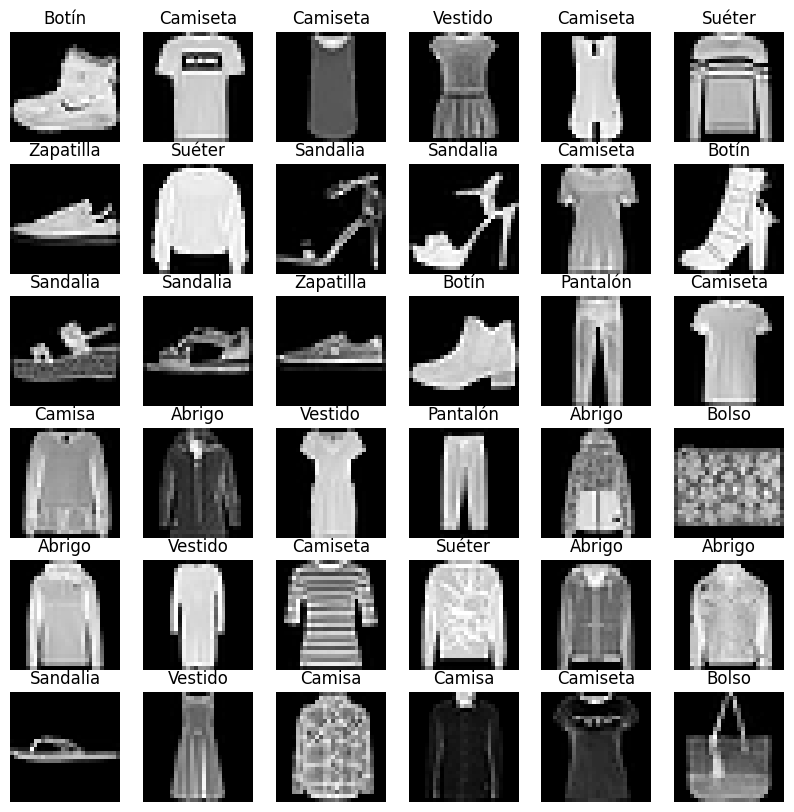

In [2]:
# Nombres de clases
clases = ['Camiseta', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
          'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

# Mostrar ejemplos
plt.figure(figsize=(10,10))
for i in range(36):
    plt.subplot(6,6,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(clases[y_train[i]])
    plt.axis('off')
plt.show()

In [3]:
# Normalizar los datos (0–255 → 0–1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Aplanar las imágenes (28x28 → 784)
X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)

# One-hot encoding de las etiquetas
Y_train = keras.utils.to_categorical(y_train, 10)
Y_test = keras.utils.to_categorical(y_test, 10)

# Verificamos dimensiones
print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)

X_train: (60000, 784)
Y_train: (60000, 10)


En la carga y pre-procresamiento de datos se hicieron los elementos descritos a continuación:

*   Se normalizaron los valores de los píxeles dividiéndolos por 255, con el objetivo de llevarlos a un rango entre 0 y 1. Esto mejora la estabilidad del entrenamiento y permite una mejor convergencia del modelo, escalando los valores para evitar números grandes.
*   Las imágenes de 28x28 píxeles fueron transformadas a vectores unidimensionales de 784 elementos, ya que las redes MLP requieren entradas en formato vectorial.
*   Las etiquetas fueron convertidas a formato one-hot encoding, lo que permite representar cada clase como un vector binario, facilitando el uso de la función de pérdida para clasificación multiclase.

#Definición del modelo

In [26]:
# seteamos los seed para números random:

np.random.seed(30)
tf.random.set_seed(30)

# Definimos las dimensiones de entrada y salida
N = X_train.shape[1]  # Dimensiones de entrada (784 píxeles)
C = Y_train.shape[1]  # Número de clases de salida (10 clases)

# Creación de la red:

h1 = 512
h2 = 256

# Creación de las capas del modelo, acompañadas de Dropout

model_dropout = keras.Sequential()
model_dropout.add(keras.layers.Dense(h1, input_dim=N, activation='relu'))
model_dropout.add(keras.layers.Dropout(0.3))
model_dropout.add(keras.layers.Dense(h2, activation='relu'))
model_dropout.add(keras.layers.Dropout(0.3))
model_dropout.add(keras.layers.Dense(h2, activation='relu'))
model_dropout.add(keras.layers.Dropout(0.3))
model_dropout.add(keras.layers.Dense(C, activation='softmax'))

model_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', "Recall", tf.keras.metrics.F1Score(name='f1', average='macro')]
)

# Aplicación de EarlyStopping
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience = 5) #<- cambiar valores de paciencia para mejorar resultado
mc = ModelCheckpoint('best_model.h5', monitor='val_loss', mode='min', verbose=1, save_best_only=True)

model_dropout.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 601,610 (2.29 MB)

 Trainable params: 601,610 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

A continuación, se implementó una red neuronal multicapa (MLP) compuesta por tres capas densas. Las capas ocultas utilizan la función de activación ReLu, la cual permite una mejor propagación del gradiente y acelera el proceso de aprendizaje.

La capa de salida utiliza la función Softmax, que transforma las salidas en probabilidades, permitiendo clasificar las imágenes en una de las 10 categorías disponibles.

Se utilizó la función de pérdida categorical_crossentropy, adecuada para problemas de clasificación multiclase con etiquetas codificadas en formato one-hot encoding.

El optimizador seleccionado fue Adam, debido a su capacidad de ajustar automáticamente la tasa de aprendizaje y mejorar la convergencia del modelo.

#Entrenamiento y ajuste de hiperparámetros

In [27]:
history_modelcheckpoint = model_dropout.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[es, mc]
)

# Carga el modelo guardado
saved_model = load_model('best_model.h5')

Epoch 1/20
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Recall: 0.6180 - accuracy: 0.7169 - f1: 0.7134 - loss: 0.7780
Epoch 1: val_loss improved from None to 0.43168, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - Recall: 0.7139 - accuracy: 0.7831 - f1: 0.7811 - loss: 0.6024 - val_Recall: 0.7817 - val_accuracy: 0.8410 - val_f1: 0.8422 - val_loss: 0.4317
Epoch 2/20
1486/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Recall: 0.7912 - accuracy: 0.8359 - f1: 0.8349 - loss: 0.4598
Epoch 2: val_loss improved from 0.43168 to 0.39873, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - Recall: 0.7952 - accuracy: 0.8369 - f1: 0.8354 - loss: 0.4497 - val_Recall: 0.8138 - val_accuracy: 0.8529 - val_f1: 0.8512 - val_loss: 0.3987
Epoch 3/20
1485/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Recall: 0.8047 - accuracy: 0.8451 - f1: 0.8444 - loss: 0.4296
Epoch 3: val_loss improved from 0.39873 to 0.37196, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - Recall: 0.8103 - accuracy: 0.8493 - f1: 0.8481 - loss: 0.4190 - val_Recall: 0.8258 - val_accuracy: 0.8621 - val_f1: 0.8605 - val_loss: 0.3720
Epoch 4/20
1493/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Recall: 0.8178 - accuracy: 0.8545 - f1: 0.8534 - loss: 0.4025
Epoch 4: val_loss improved from 0.37196 to 0.36278, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - Recall: 0.8214 - accuracy: 0.8567 - f1: 0.8553 - loss: 0.3962 - val_Recall: 0.8309 - val_accuracy: 0.8658 - val_f1: 0.8660 - val_loss: 0.3628
Epoch 5/20
1485/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Recall: 0.8241 - accuracy: 0.8571 - f1: 0.8563 - loss: 0.3895
Epoch 5: val_loss improved from 0.36278 to 0.35408, saving model to best_model.h5


...


Epoch 8: finished saving model to best_model.h5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - Recall: 0.8456 - accuracy: 0.8742 - f1: 0.8734 - loss: 0.3475 - val_Recall: 0.8543 - val_accuracy: 0.8814 - val_f1: 0.8809 - val_loss: 0.3332
Epoch 9/20
1492/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Recall: 0.8484 - accuracy: 0.8758 - f1: 0.8755 - loss: 0.3441
Epoch 9: val_loss did not improve from 0.33323
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - Recall: 0.8520 - accuracy: 0.8783 - f1: 0.8775 - loss: 0.3374 - val_Recall: 0.8438 - val_accuracy: 0.8773 - val_f1: 0.8771 - val_loss: 0.3442
Epoch 10/20
1493/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Recall: 0.8478 - accuracy: 0.8760 - f1: 0.8757 - loss: 0.3472
Epoch 10: val_loss did not improve from 0.33323
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - Recall: 0.8511 - accuracy: 0.8779 - f1: 0.8771 - loss: 0.3399 - val_Recall: 0.8397 - val_accuracy: 0.8772 - val_f1: 0.8753 - val_loss: 0.3424
Epoch 11/20
1487/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - R


Epoch 12: finished saving model to best_model.h5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - Recall: 0.8584 - accuracy: 0.8830 - f1: 0.8823 - loss: 0.3232 - val_Recall: 0.8575 - val_accuracy: 0.8822 - val_f1: 0.8815 - val_loss: 0.3249
Epoch 13/20
1487/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Recall: 0.8603 - accuracy: 0.8834 - f1: 0.8831 - loss: 0.3212
Epoch 13: val_loss did not improve from 0.32494
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - Recall: 0.8603 - accuracy: 0.8830 - f1: 0.8822 - loss: 0.3185 - val_Recall: 0.8600 - val_accuracy: 0.8822 - val_f1: 0.8819 - val_loss: 0.3270
Epoch 14/20
1491/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Recall: 0.8602 - accuracy: 0.8836 - f1: 0.8834 - loss: 0.3185
Epoch 14: val_loss improved from 0.32494 to 0.32271, saving model to best_model.h5



Epoch 14: finished saving model to best_model.h5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - Recall: 0.8625 - accuracy: 0.8853 - f1: 0.8847 - loss: 0.3130 - val_Recall: 0.8636 - val_accuracy: 0.8870 - val_f1: 0.8860 - val_loss: 0.3227
Epoch 15/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Recall: 0.8571 - accuracy: 0.8818 - f1: 0.8815 - loss: 0.3222
Epoch 15: val_loss did not improve from 0.32271
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - Recall: 0.8607 - accuracy: 0.8840 - f1: 0.8834 - loss: 0.3142 - val_Recall: 0.8637 - val_accuracy: 0.8846 - val_f1: 0.8841 - val_loss: 0.3256
Epoch 16/20
1490/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Recall: 0.8664 - accuracy: 0.8887 - f1: 0.8886 - loss: 0.3091
Epoch 16: val_loss improved from 0.32271 to 0.32209, saving model to best_model.h5



Epoch 16: finished saving model to best_model.h5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - Recall: 0.8682 - accuracy: 0.8902 - f1: 0.8896 - loss: 0.3047 - val_Recall: 0.8601 - val_accuracy: 0.8838 - val_f1: 0.8830 - val_loss: 0.3221
Epoch 17/20
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Recall: 0.8641 - accuracy: 0.8889 - f1: 0.8887 - loss: 0.3077
Epoch 17: val_loss did not improve from 0.32209
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - Recall: 0.8676 - accuracy: 0.8905 - f1: 0.8898 - loss: 0.3016 - val_Recall: 0.8602 - val_accuracy: 0.8846 - val_f1: 0.8842 - val_loss: 0.3290
Epoch 18/20
1490/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Recall: 0.8656 - accuracy: 0.8889 - f1: 0.8888 - loss: 0.3096
Epoch 18: val_loss did not improve from 0.32209
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - Recall: 0.8693 - accuracy: 0.8911 - f1: 0.8905 - loss: 0.3000 - val_Recall: 0.8562 - val_accuracy: 0.8823 - val_f1: 0.8816 - val_loss: 0.3345
Epoch 19/20
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


Epoch 19: finished saving model to best_model.h5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - Recall: 0.8690 - accuracy: 0.8906 - f1: 0.8901 - loss: 0.2984 - val_Recall: 0.8637 - val_accuracy: 0.8859 - val_f1: 0.8856 - val_loss: 0.3206
Epoch 20/20
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Recall: 0.8711 - accuracy: 0.8929 - f1: 0.8928 - loss: 0.2933
Epoch 20: val_loss did not improve from 0.32060
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - Recall: 0.8728 - accuracy: 0.8943 - f1: 0.8937 - loss: 0.2916 - val_Recall: 0.8648 - val_accuracy: 0.8854 - val_f1: 0.8851 - val_loss: 0.3325


Se decidió utilizar las configuraciones mostradas con anterioridad con los siguientes objetivos en mente:

*   Epochs: se utilizaron 20 epochs con el propósito de comenzar con valores normales para comprender si el entrenamiento del modelo mejora continuamente, en lugar de iniciar con valores más altos, lo que puede dar paso al Overfitting del modelo.
*   Batch size: se inició con 32 batch debido a su centralidad dentro de los valores típicos utilizados en los batch comunmente. Al ser un valor central dentro de los demás valores, se comprende que con un valor más bajo pude haber más ruido, así como también se entiende que con un valor mucho más alto puede haber riesgo de overfitting.
*   Validation Split: se seleccionó un 20% del entrenamiento para la validación basándonos en las buenas prácticas de separación de 80/20, sin utilizar menos ni más al considerar el tamaño moderado del dataset y el equilibrio en la cantidad de datos necesarios para validar la capacidad de generalización del modelo.





#Evaluación del modelo

####Modelo inicial 20 épocas

In [30]:
print(f"Train accuracy \u2248 {history.history['accuracy'][-1]*100:.1f}%")
print(f"Val accuracy \u2248 {history.history['val_accuracy'][-1]*100:.1f}%")

Train accuracy ≈ 93.9%
Val accuracy ≈ 88.5%


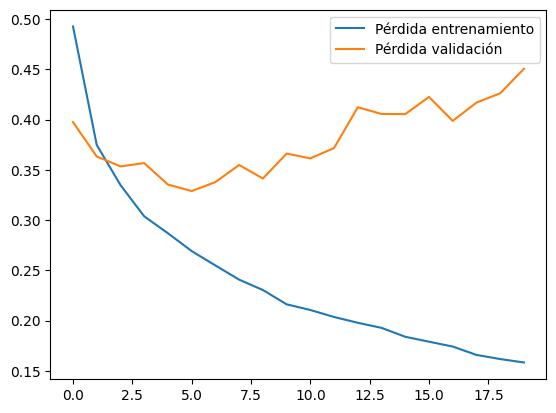

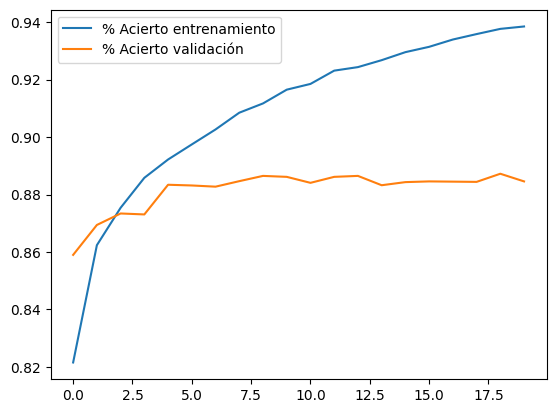

In [31]:
# Gráficamos las perdidas y los aciertos por cada época

plt.plot(history.history['loss'], label='Pérdida entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida validación')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='% Acierto entrenamiento')
plt.plot(history.history['val_accuracy'], label='% Acierto validación')
plt.legend()
plt.show()

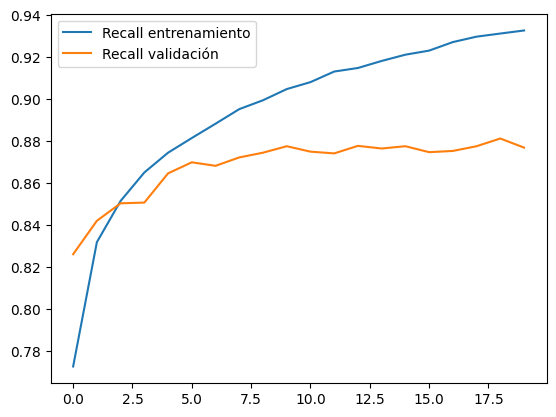

In [32]:
plt.plot(history.history['Recall'], label='Recall entrenamiento')
plt.plot(history.history['val_Recall'], label='Recall validación')
plt.legend()
plt.show()

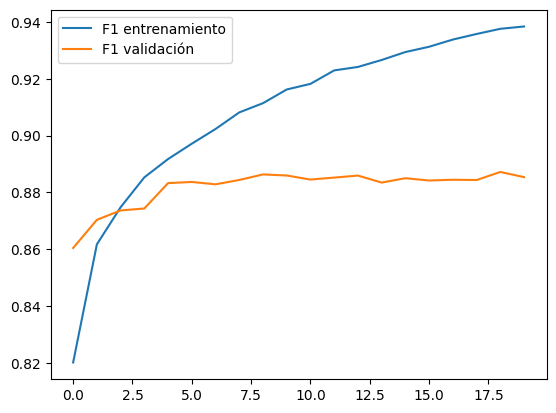

In [33]:
plt.plot(history.history['f1'], label='F1 entrenamiento')
plt.plot(history.history['val_f1'], label='F1 validación')
plt.legend()
plt.show()

####Modelo 30 épocas

In [8]:
print(f"Train accuracy \u2248 {history_aumento.history['accuracy'][-1]*100:.1f}%")
print(f"Val accuracy \u2248 {history_aumento.history['val_accuracy'][-1]*100:.1f}%")

Train accuracy ≈ 95.5%
Val accuracy ≈ 88.3%


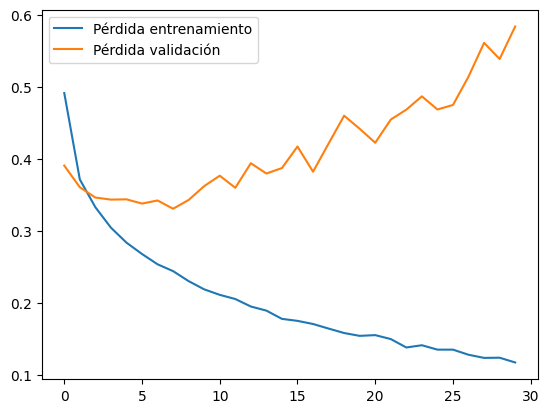

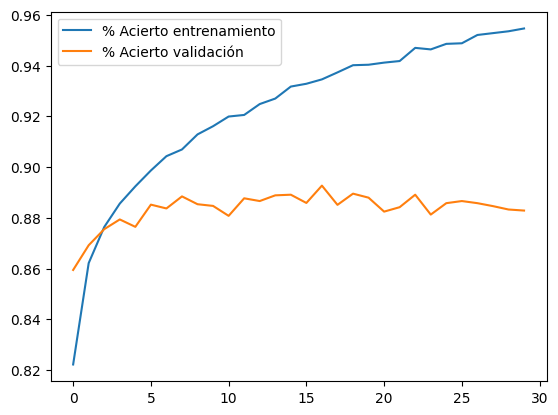

In [9]:
# Gráficamos las perdidas y los aciertos por cada época

plt.plot(history_aumento.history['loss'], label='Pérdida entrenamiento')
plt.plot(history_aumento.history['val_loss'], label='Pérdida validación')
plt.legend()
plt.show()

plt.plot(history_aumento.history['accuracy'], label='% Acierto entrenamiento')
plt.plot(history_aumento.history['val_accuracy'], label='% Acierto validación')
plt.legend()
plt.show()

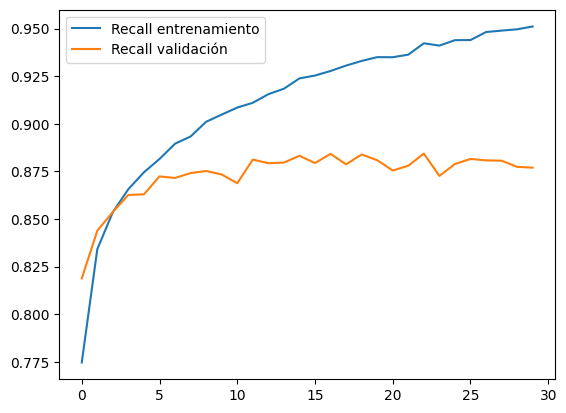

In [10]:
plt.plot(history_aumento.history['Recall'], label='Recall entrenamiento')
plt.plot(history_aumento.history['val_Recall'], label='Recall validación')
plt.legend()
plt.show()

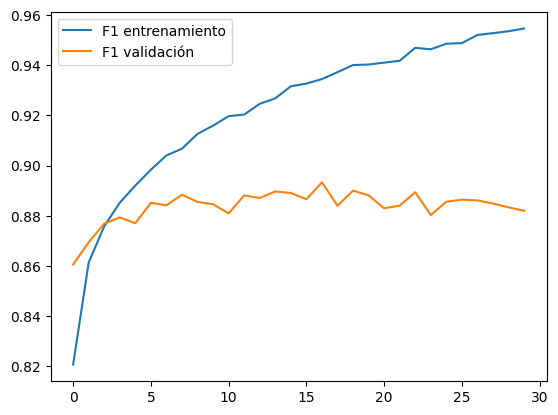

In [11]:
plt.plot(history_aumento.history['f1'], label='F1 entrenamiento')
plt.plot(history_aumento.history['val_f1'], label='F1 validación')
plt.legend()
plt.show()

####Modelo 10 épocas

In [14]:
print(f"Train accuracy \u2248 {history_disminucion.history['accuracy'][-1]*100:.1f}%")
print(f"Val accuracy \u2248 {history_disminucion.history['val_accuracy'][-1]*100:.1f}%")

Train accuracy ≈ 96.3%
Val accuracy ≈ 87.9%


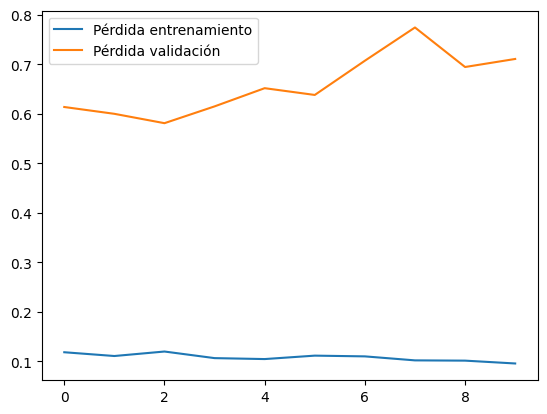

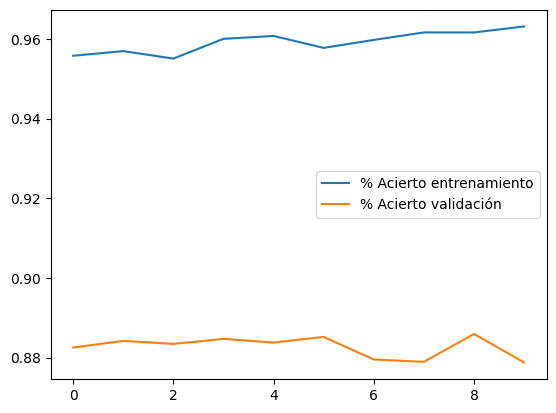

In [15]:
# Gráficamos las perdidas y los aciertos por cada época

plt.plot(history_disminucion.history['loss'], label='Pérdida entrenamiento')
plt.plot(history_disminucion.history['val_loss'], label='Pérdida validación')
plt.legend()
plt.show()

plt.plot(history_disminucion.history['accuracy'], label='% Acierto entrenamiento')
plt.plot(history_disminucion.history['val_accuracy'], label='% Acierto validación')
plt.legend()
plt.show()

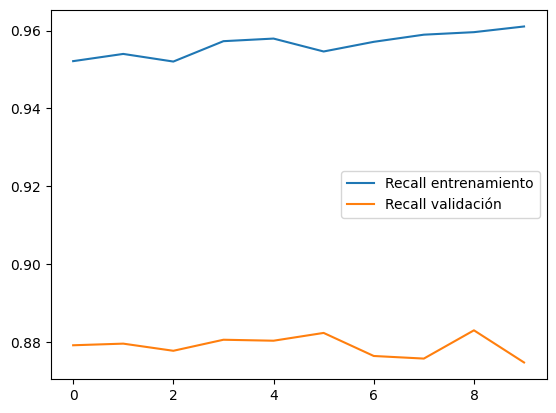

In [16]:
plt.plot(history_disminucion.history['Recall'], label='Recall entrenamiento')
plt.plot(history_disminucion.history['val_Recall'], label='Recall validación')
plt.legend()
plt.show()

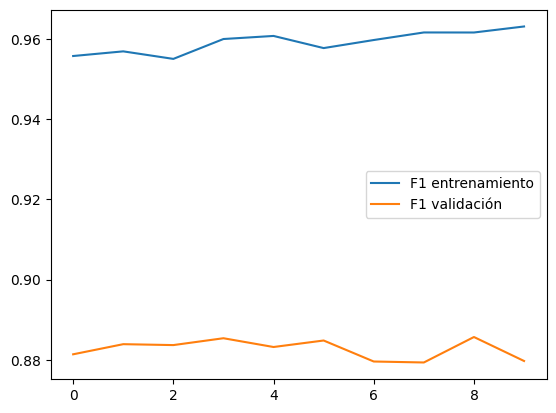

In [17]:
plt.plot(history_disminucion.history['f1'], label='F1 entrenamiento')
plt.plot(history_disminucion.history['val_f1'], label='F1 validación')
plt.legend()
plt.show()

####Modelo dropout

In [6]:
print(f"Train accuracy \u2248 {history_dropout.history['accuracy'][-1]*100:.1f}%")
print(f"Val accuracy \u2248 {history_dropout.history['val_accuracy'][-1]*100:.1f}%")

Train accuracy ≈ 89.1%
Val accuracy ≈ 88.8%


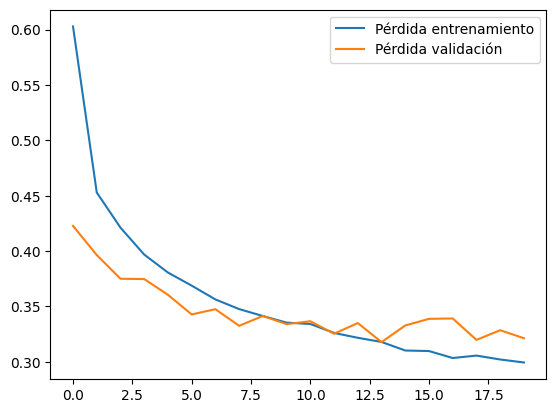

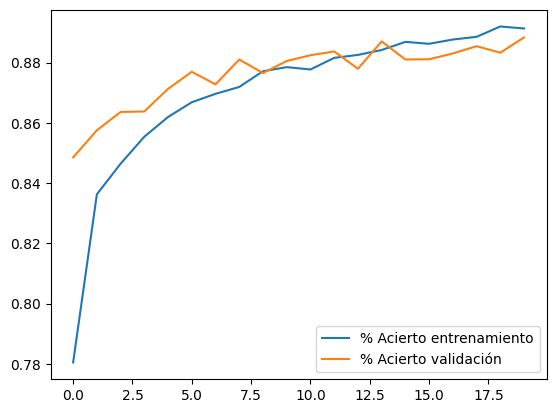

In [7]:
# Gráficamos las perdidas y los aciertos por cada época

plt.plot(history_dropout.history['loss'], label='Pérdida entrenamiento')
plt.plot(history_dropout.history['val_loss'], label='Pérdida validación')
plt.legend()
plt.show()

plt.plot(history_dropout.history['accuracy'], label='% Acierto entrenamiento')
plt.plot(history_dropout.history['val_accuracy'], label='% Acierto validación')
plt.legend()
plt.show()

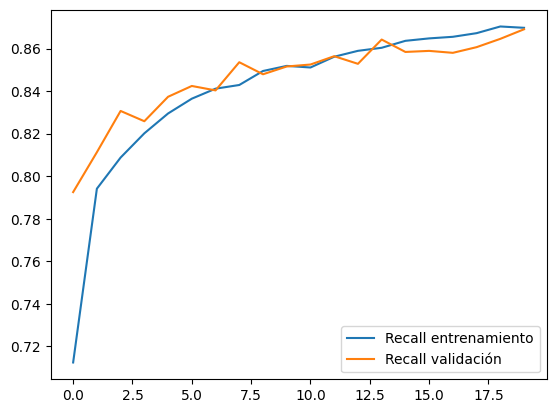

In [8]:
plt.plot(history_dropout.history['Recall'], label='Recall entrenamiento')
plt.plot(history_dropout.history['val_Recall'], label='Recall validación')
plt.legend()
plt.show()

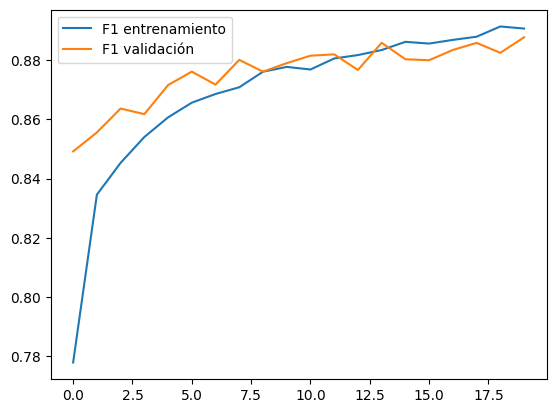

In [9]:
plt.plot(history_dropout.history['f1'], label='F1 entrenamiento')
plt.plot(history_dropout.history['val_f1'], label='F1 validación')
plt.legend()
plt.show()

####Modelo earlyStopping sin patience

In [8]:
print(f"Train accuracy \u2248 {history_earlystopping.history['accuracy'][-1]*100:.1f}%")
print(f"Val accuracy \u2248 {history_earlystopping.history['val_accuracy'][-1]*100:.1f}%")

Train accuracy ≈ 86.3%
Val accuracy ≈ 86.4%


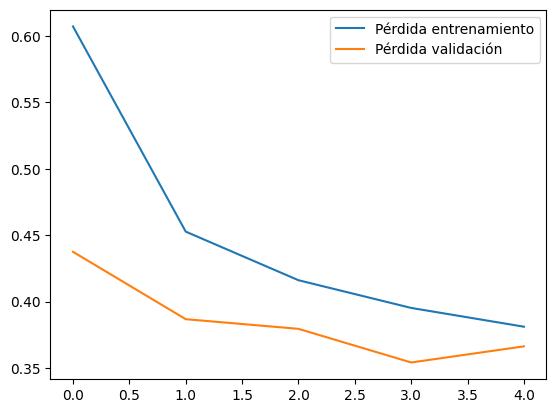

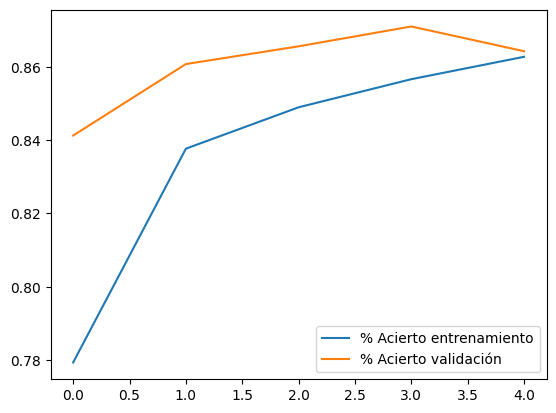

In [9]:
plt.plot(history_earlystopping.history['loss'], label='Pérdida entrenamiento')
plt.plot(history_earlystopping.history['val_loss'], label='Pérdida validación')
plt.legend()
plt.show()

plt.plot(history_earlystopping.history['accuracy'], label='% Acierto entrenamiento')
plt.plot(history_earlystopping.history['val_accuracy'], label='% Acierto validación')
plt.legend()
plt.show()

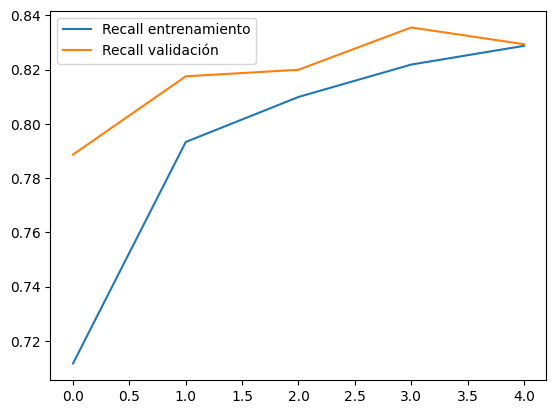

In [10]:
plt.plot(history_earlystopping.history['Recall'], label='Recall entrenamiento')
plt.plot(history_earlystopping.history['val_Recall'], label='Recall validación')
plt.legend()
plt.show()

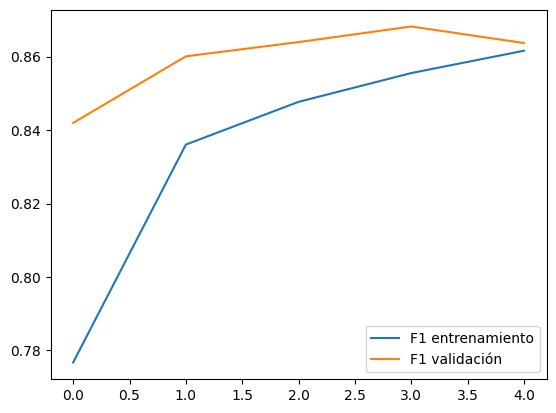

In [11]:
plt.plot(history_earlystopping.history['f1'], label='F1 entrenamiento')
plt.plot(history_earlystopping.history['val_f1'], label='F1 validación')
plt.legend()
plt.show()

####Modelo earlyStopping con patience

In [14]:
print(f"Train accuracy \u2248 {history_earlystopping_patience.history['accuracy'][-1]*100:.1f}%")
print(f"Val accuracy \u2248 {history_earlystopping_patience.history['val_accuracy'][-1]*100:.1f}%")

Train accuracy ≈ 88.1%
Val accuracy ≈ 88.3%


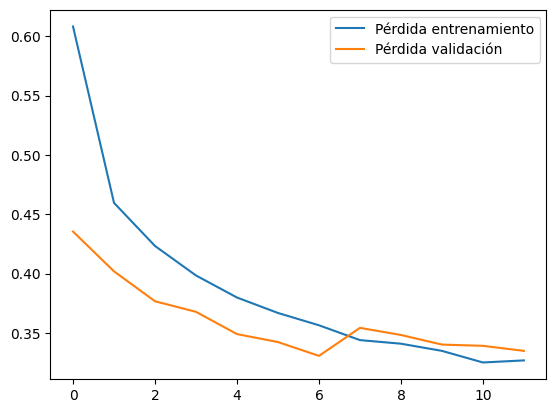

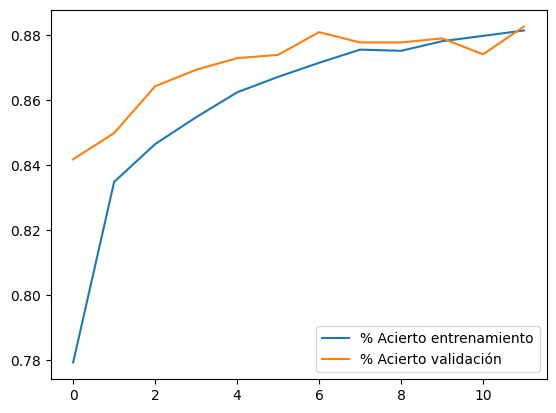

In [15]:
plt.plot(history_earlystopping_patience.history['loss'], label='Pérdida entrenamiento')
plt.plot(history_earlystopping_patience.history['val_loss'], label='Pérdida validación')
plt.legend()
plt.show()

plt.plot(history_earlystopping_patience.history['accuracy'], label='% Acierto entrenamiento')
plt.plot(history_earlystopping_patience.history['val_accuracy'], label='% Acierto validación')
plt.legend()
plt.show()

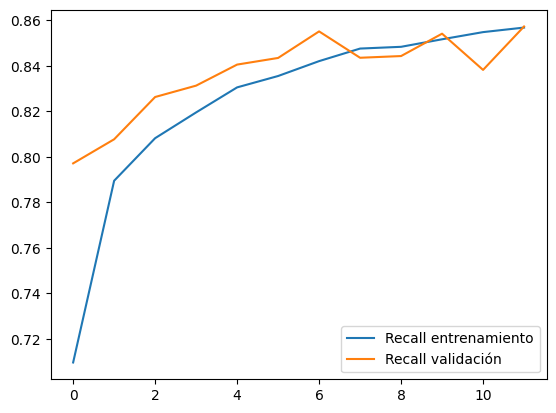

In [16]:
plt.plot(history_earlystopping_patience.history['Recall'], label='Recall entrenamiento')
plt.plot(history_earlystopping_patience.history['val_Recall'], label='Recall validación')
plt.legend()
plt.show()

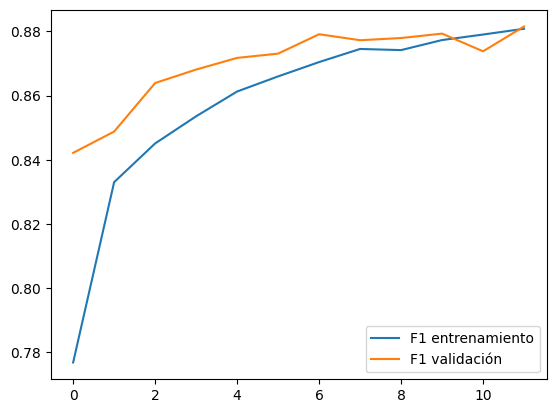

In [17]:
plt.plot(history_earlystopping_patience.history['f1'], label='F1 entrenamiento')
plt.plot(history_earlystopping_patience.history['val_f1'], label='F1 validación')
plt.legend()
plt.show()

####Modelo con modelcheckpoint

In [28]:
print(f"Train accuracy \u2248 {history_modelcheckpoint.history['accuracy'][-1]*100:.1f}%")
print(f"Val accuracy \u2248 {history_modelcheckpoint.history['val_accuracy'][-1]*100:.1f}%")

Train accuracy ≈ 89.4%
Val accuracy ≈ 88.5%


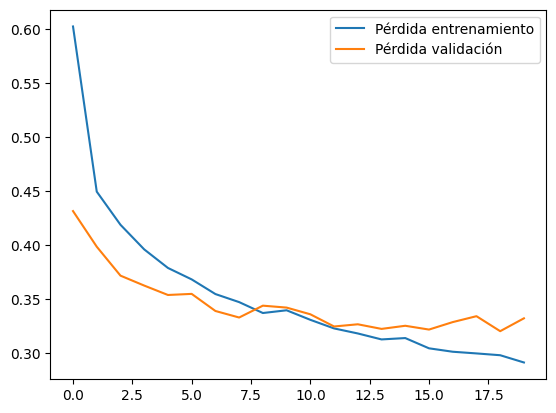

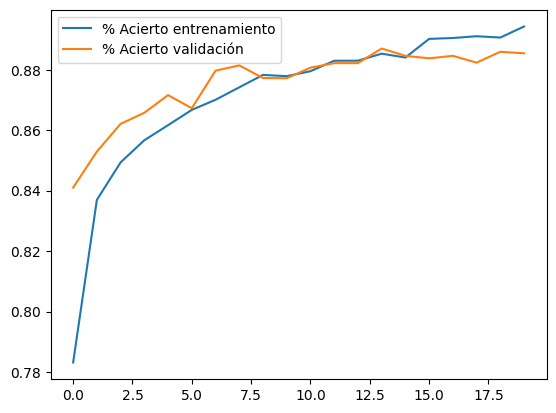

In [29]:
plt.plot(history_modelcheckpoint.history['loss'], label='Pérdida entrenamiento')
plt.plot(history_modelcheckpoint.history['val_loss'], label='Pérdida validación')
plt.legend()
plt.show()

plt.plot(history_modelcheckpoint.history['accuracy'], label='% Acierto entrenamiento')
plt.plot(history_modelcheckpoint.history['val_accuracy'], label='% Acierto validación')
plt.legend()
plt.show()

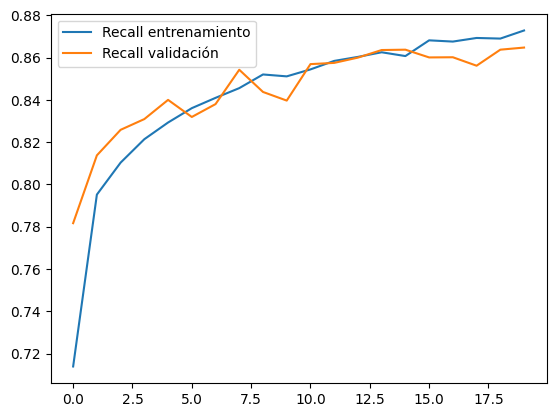

In [30]:
plt.plot(history_modelcheckpoint.history['Recall'], label='Recall entrenamiento')
plt.plot(history_modelcheckpoint.history['val_Recall'], label='Recall validación')
plt.legend()
plt.show()

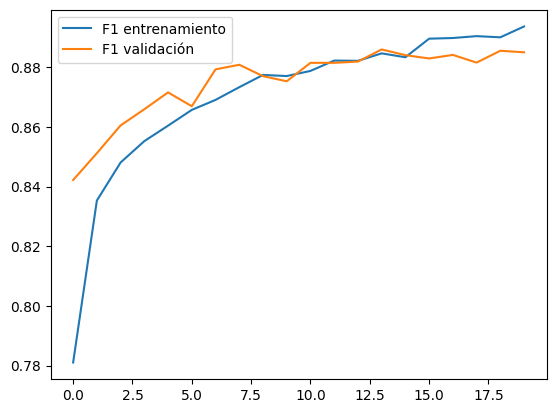

In [31]:
plt.plot(history_modelcheckpoint.history['f1'], label='F1 entrenamiento')
plt.plot(history_modelcheckpoint.history['val_f1'], label='F1 validación')
plt.legend()
plt.show()

#Análisis y mejora del modelo

A continuación se detallarán los cambios impuestos en el desarrollo del modelo para obtención de mejores resultados en el entrenamiento.

*   Inicialmente se trabajó un modelo sin algún tipo de regularización o implementación extra. Se presentó un claro caso de Overfitting, donde el modelo memorizó los datos y no logró aprender patrones para la posterior validación.

*   Se decidió modificar la cantidad de Épocas durante el entrenamiento del modelo. Se aumentaron 10 Épocas en base a las 20 anteriores (20 -> 30), así como también se quitaron 10 (20 -> 10). Si bien cambiaron los resultados, los gráficos representaron un Overfitting mayor y un aprendizaje más bajo que en los entrenamientos pasados, por lo que es mejor mantener 20 épocas para este.


*   Posteriormente se buscó trabajar con la técnica de regularización Dropout, permitiendonos desactivar neuronas al azar para mejorar la robustez de aprendizaje del modelo. Se nota una mejoría clara en el aprendizaje de este, demostrando una alta capacidad de aprendizaje y una menor pérdida entre los valores validados.

*   Luego de trabajar con Dropout se buscó utilizar otras técnicas de regularización, en este caso, EarlyStopping, aplicando parámetros como "val_loss", "min" y "verbose". Al no determinar una paciencia exacta sobre el entrenamiento, este terminó demasiado pronto, más especificamente, en la época número 5. Por esta razón en particular, se decidió determinar un nivel de paciencia de 5 épocas, dando paso a un modelo el cual finalizó su entrenamiento tras 12 épocas.

*   Tras trabajar con earlyStopping y la paciencia de este, se utilizó ModelCheckpoint para poder guardar el mejor modelo con la mayor perdida en la validación. En este caso el modelo fue guardado en la época 19, en la que se detectó la mayor pérdida de un total de 20 épocas.

#Conclusiones